Explainable AI for Binary Classification of Melanoma Skin Cancer

In [ ]:
import os #Used to work with folders and file paths
import numpy as np #Used for numerical operations and arrays
import pandas as pd #Used to load and handle CSV metadata
import matplotlib.pyplot as plt  #Used for visualization (graphs, images


In [ ]:
df = pd.read_csv("ISIC_2020_Train_Metadata.csv")
df.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


In [ ]:
df.isnull().sum()

,0
image_name,0
patient_id,0
lesion_id,0
sex,65
age_approx,68
anatom_site_general_challenge,527
diagnosis,0
benign_malignant,0
target,0


In [ ]:
df_clean = df.dropna()

In [ ]:
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (33126, 9)
After: (32531, 9)


In [ ]:
df_clean = df.dropna(subset=['age_approx'])

In [ ]:
df_clean = df.dropna(axis=1)

In [ ]:
df_clean.isnull().sum()

,0
image_name,0
patient_id,0
lesion_id,0
diagnosis,0
benign_malignant,0
target,0


In [ ]:
df['target'].value_counts(normalize=True)

,proportion
target,
0,0.98237
1,0.01763


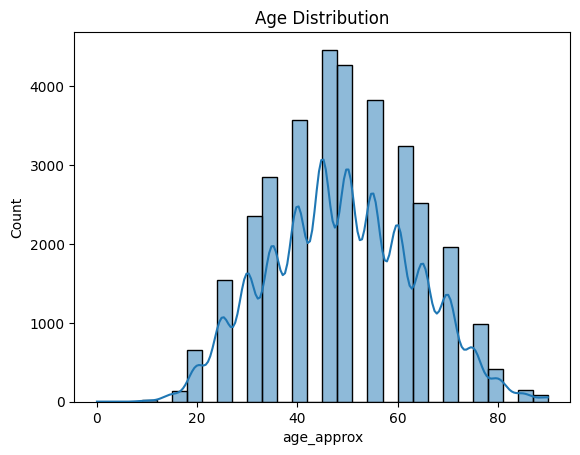

In [ ]:
import seaborn as sns
plt.figure()
sns.histplot(df['age_approx'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

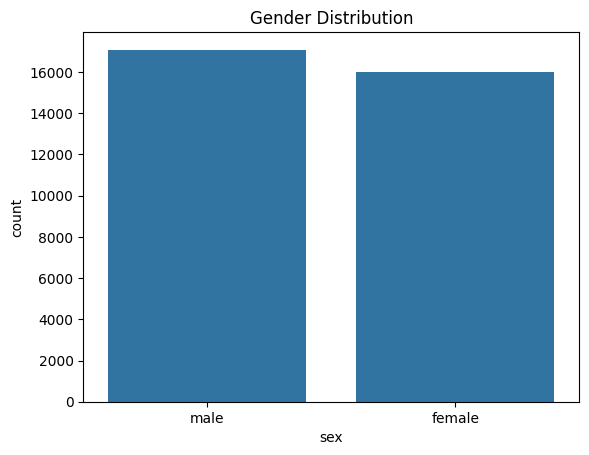

In [ ]:
plt.figure()
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

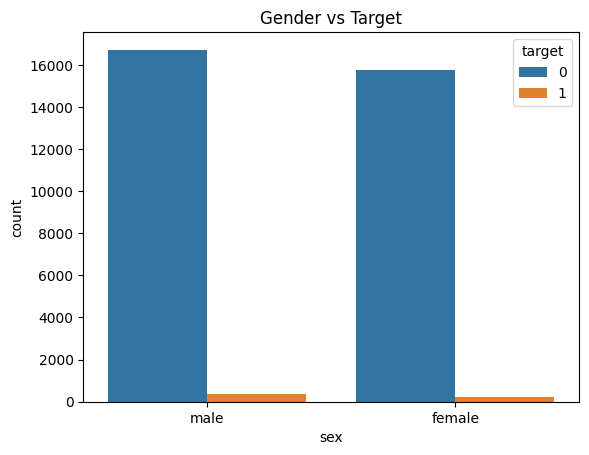

In [ ]:
plt.figure()
sns.countplot(x='sex', hue='target', data=df)
plt.title("Gender vs Target")
plt.show()

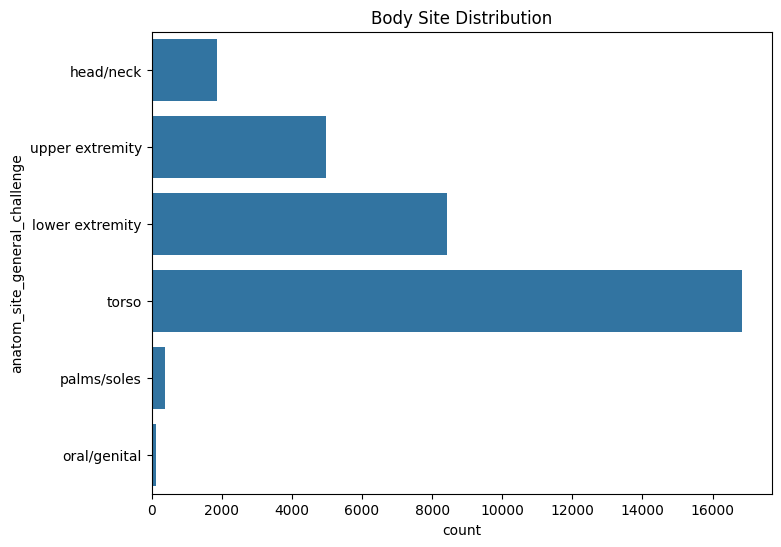

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(y='anatom_site_general_challenge', data=df)
plt.title("Body Site Distribution")
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['target'],
    random_state=34
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 26500
Test: 6626


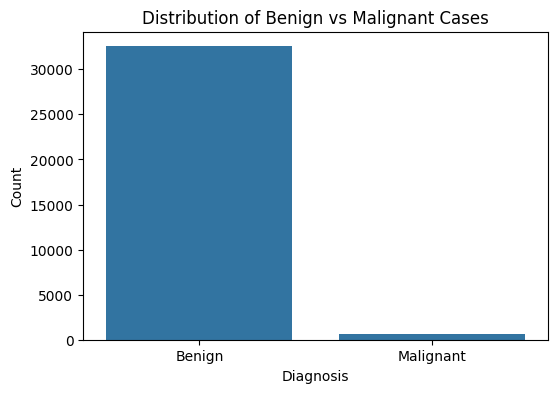

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)

plt.xticks([0,1], ['Benign', 'Malignant'])
plt.title("Distribution of Benign vs Malignant Cases")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Exact counts
counts = df['target'].value_counts()

benign = counts.get(0, 0)
malignant = counts.get(1, 0)

print("Exact Number of Benign Cases:", benign)
print("Exact Number of Malignant Cases:", malignant)

Exact Number of Benign Cases: 32542
Exact Number of Malignant Cases: 584


In [ ]:
male_count = df[df['sex'] == 'male'].shape[0]
female_count = df[df['sex'] == 'female'].shape[0]

print("Number of Male patients:", male_count)
print("Number of Female patients:", female_count)

Number of Male patients: 17080
Number of Female patients: 15981


In [ ]:
# Cross-tabulation
import pandas as pd

table = pd.crosstab(df['sex'], df['target'])
table.columns = ['Benign', 'Malignant']

print(table)

        Benign  Malignant
sex                      
female   15761        220
male     16716        364
